In [6]:
import numpy as np
import pandas as pd
from collections import Counter
df=pd.read_csv(r"C:/Users/asros/Downloads/archive (1).zip")
#drop ID column
df.drop("ID", axis=1, inplace=True)
#seperate features and label
x = df.drop("default.payment.next.month", axis=1).values
y = df["default.payment.next.month"].values
x = (x - x.mean(axis=0)) / x.std(axis=0)#normalize features
#train-test split
np.random.seed(42)
indices = np.random.permutation(len(x))
train_size = int(0.8 * len(x))
train_idx = indices[:train_size]
test_idx = indices[train_size:]
x_train, x_test = x[train_idx], x[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
#knn code
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))
def knn_predict(x_train,y_train, test_point, k):
    distances = []
    for i in range(len(x_train)):
        dist = euclidean_distance(test_point, x_train[i])
        distances.append((dist, y_train[i]))
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]
#make predictions
k=5
predictions=[]
for x in x_test:
    predictions.append(knn_predict(x_train,y_train,x,k))
predictions=np.array(predictions)
#accuracy
accuracy=np.mean(predictions==y_test)
print("Accuracy:",accuracy)

Accuracy: 0.7848333333333334


(30000, 24)
(30000,)
5.976700615898759e-18
1.0
[[4302  371]
 [ 868  459]]
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.55      0.35      0.43      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.63      0.65      6000
weighted avg       0.77      0.79      0.77      6000

Before SMOTE: Counter({0: 18691, 1: 5309})
After SMOTE: Counter({0: 18691, 1: 18691})
[[3124 1549]
 [ 517  810]]
              precision    recall  f1-score   support

           0       0.86      0.67      0.75      4673
           1       0.34      0.61      0.44      1327

    accuracy                           0.66      6000
   macro avg       0.60      0.64      0.60      6000
weighted avg       0.74      0.66      0.68      6000



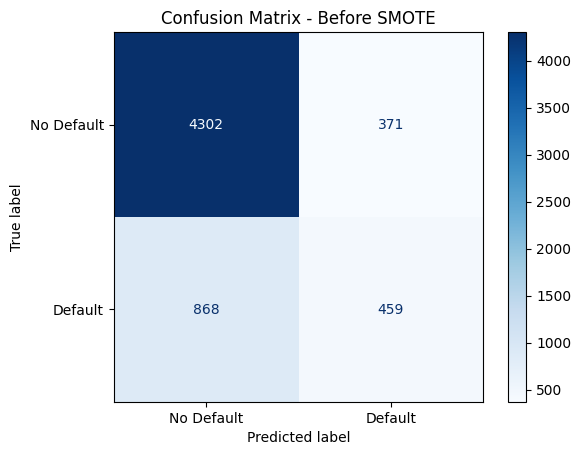

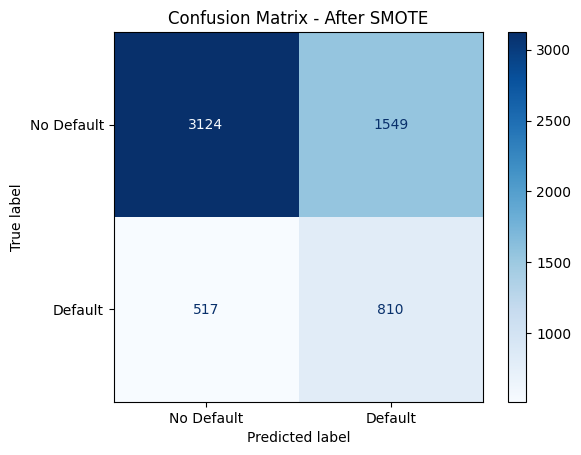

,Metric,Before SMOTE,After SMOTE
0,Accuracy,0.79,0.66
1,Precision (Default),0.55,0.34
2,Recall (Default),0.35,0.61
3,F1-score (Default),0.43,0.44


In [6]:
import pandas as pd

df=pd.read_csv(r"C:/Users/asros/Downloads/archive (1).zip")#r reads as is it
df.head()
df.shape
x = df.drop('default.payment.next.month', axis=1)
#drop removes target from inputs
#axis drops one collum 
# #x are all the features 
#y is what knn will predict
y = df['default.payment.next.month']
print(x.shape)
print(y.shape)

#split data and preserve class imbalance using stratification
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2, #80%train 20%test
    random_state=42, #uses the same random pattern everytime(reproducibility)(any integer works)
    stratify=y  #without this test set might lose class ratio(keeps same class ratio)
    #since it is already 95% no default and 5%default
)

#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)#learns scaling parameters and applies them
#learns mean &std from x_train and stores into scaler(or how to scale)
#x_train_scaled stores the scaled value
x_test_scaled = scaler.transform(x_test)#applies learned parameters
print(x_train_scaled.mean())
print(x_train_scaled.std())
#scaled values are how much abv or below average
#z(scaled value) = x- myu(mean) / sigma(standard deviation)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

y_pred = knn.predict(x_test_scaled)#make predictions

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
#[[TN FP][FN TP]]
#FN value is high
print(classification_report(y_test, y_pred))
#data for minority class(below) recall only caught 35%(banks would lose money)

#The KNN model achieves reasonable overall accuracy, 
# but performs poorly on the minority class with a recall of only 0.35.
# This indicates that the model fails to identify a large proportion of defaulters due to class imbalance, 
# making accuracy an unreliable metric in this scenario.

#applying SMOTE-Synthetic Minority Over-sampling Technique
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(
    x_train_scaled, y_train
)
from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))
#Before SMOTE - Minority points were isolated
#             -&Majority neighbors dominated votes
#After SMOTE -Minority neighborhoods are denser
#            & KNN can correctly classify defaulters

#After applying SMOTE, the training dataset becomes perfectly balanced, 
# allowing the KNN classifier to learn decision boundaries for 
# the minority class more effectively without introducing data leakage

#train KNN after SMOTE & compare results
from sklearn.neighbors import KNeighborsClassifier
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(x_train_smote, y_train_smote)
y_pred_smote = knn_smote.predict(x_test_scaled)
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

#Applying SMOTE significantly improved the KNN classifier’s ability to detect the minority class. 
# Recall for defaulters increased from 0.35 to 0.61, 
# and the number of false negatives reduced substantially. 
# Although overall accuracy decreased, this trade-off is acceptable 
# because identifying defaulters is more critical than maximizing accuracy in an imbalanced dataset.

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Default", "Default"],
    cmap="Blues"
)
plt.title("Confusion Matrix - Before SMOTE")
plt.show()
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_smote,
    display_labels=["No Default", "Default"],
    cmap="Blues"
)
plt.title("Confusion Matrix - After SMOTE")
plt.show()
#After SMOTE, the number of true positives increases while 
#false negatives decrease, indicating improved detection of defaulters.

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Default)", "Recall (Default)", "F1-score (Default)"],
    "Before SMOTE": [0.79, 0.55, 0.35, 0.43],
    "After SMOTE":  [0.66, 0.34, 0.61, 0.44]
})
comparison
#While accuracy decreases after SMOTE, recall for the minority class improves significantly, 
#showing that the model becomes more effective at identifying defaulters.

#KNN performance on the imbalanced dataset showed high accuracy 
# but poor recall for the minority class. 
# After applying SMOTE, recall improved substantially 
# at the cost of increased false positives and reduced accuracy. 
# This trade-off is acceptable in credit default prediction, 
# where missing a defaulter is more costly than incorrectly flagging a non-defaulter. 
# Therefore, SMOTE-enhanced KNN provides a more practical model for this problem
